# Домашнее задание 11: Как найти стог сена в иголке?
## Построение системы поиска аномалий в банковских транзакциях

**Цель:** Настроить систему по поиску аномалий в банковских транзакциях. Данные содержат анонимизированные переменные (первые 28 главных компонент PCA) и менее 1% аномальных наблюдений.

**План:**
1. EDA (гистограммы, описательные статистики)
2. Оценка процента аномалий по Class
3. Distance-based модели
4. Density-based модели (DBSCAN)
5. Model-based модели (Isolation Forest, One-Class SVM, Autoencoder)
6. Оценка качества (classification report, confusion matrix)
7. Визуализация через tSNE и UMAP

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split

import sys
import os

plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style('whitegrid')

## 1. Загрузка данных

In [2]:
data = pd.read_csv('creditcard.csv')
print(f'Размер датасета: {data.shape}')
data.head()

Размер датасета: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

## 2. EDA

In [4]:
# Описательные статистики
data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [5]:
# Проверка пропусков
print('Пропуски в данных:')
print(data.isnull().sum().sum())

Пропуски в данных:
0


Распределение Class:
Нормальные транзакции (0): 284315 (99.8273%)
Мошеннические транзакции (1): 492 (0.1727%)

Процент аномалий (экспертная оценка): 0.1727%


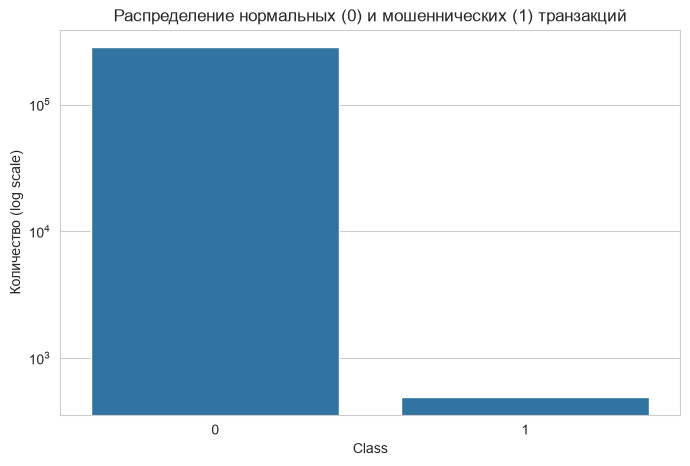

In [6]:
# Распределение целевой переменной Class
class_counts = data['Class'].value_counts()
print('Распределение Class:')
print(f'Нормальные транзакции (0): {class_counts[0]} ({100*class_counts[0]/len(data):.4f}%)')
print(f'Мошеннические транзакции (1): {class_counts[1]} ({100*class_counts[1]/len(data):.4f}%)')

anomaly_pct = 100 * class_counts[1] / len(data)
print(f'\nПроцент аномалий (экспертная оценка): {anomaly_pct:.4f}%')

plt.figure(figsize=(8, 5))
sns.countplot(x='Class', data=data)
plt.title('Распределение нормальных (0) и мошеннических (1) транзакций')
plt.yscale('log')
plt.ylabel('Количество (log scale)')
plt.show()

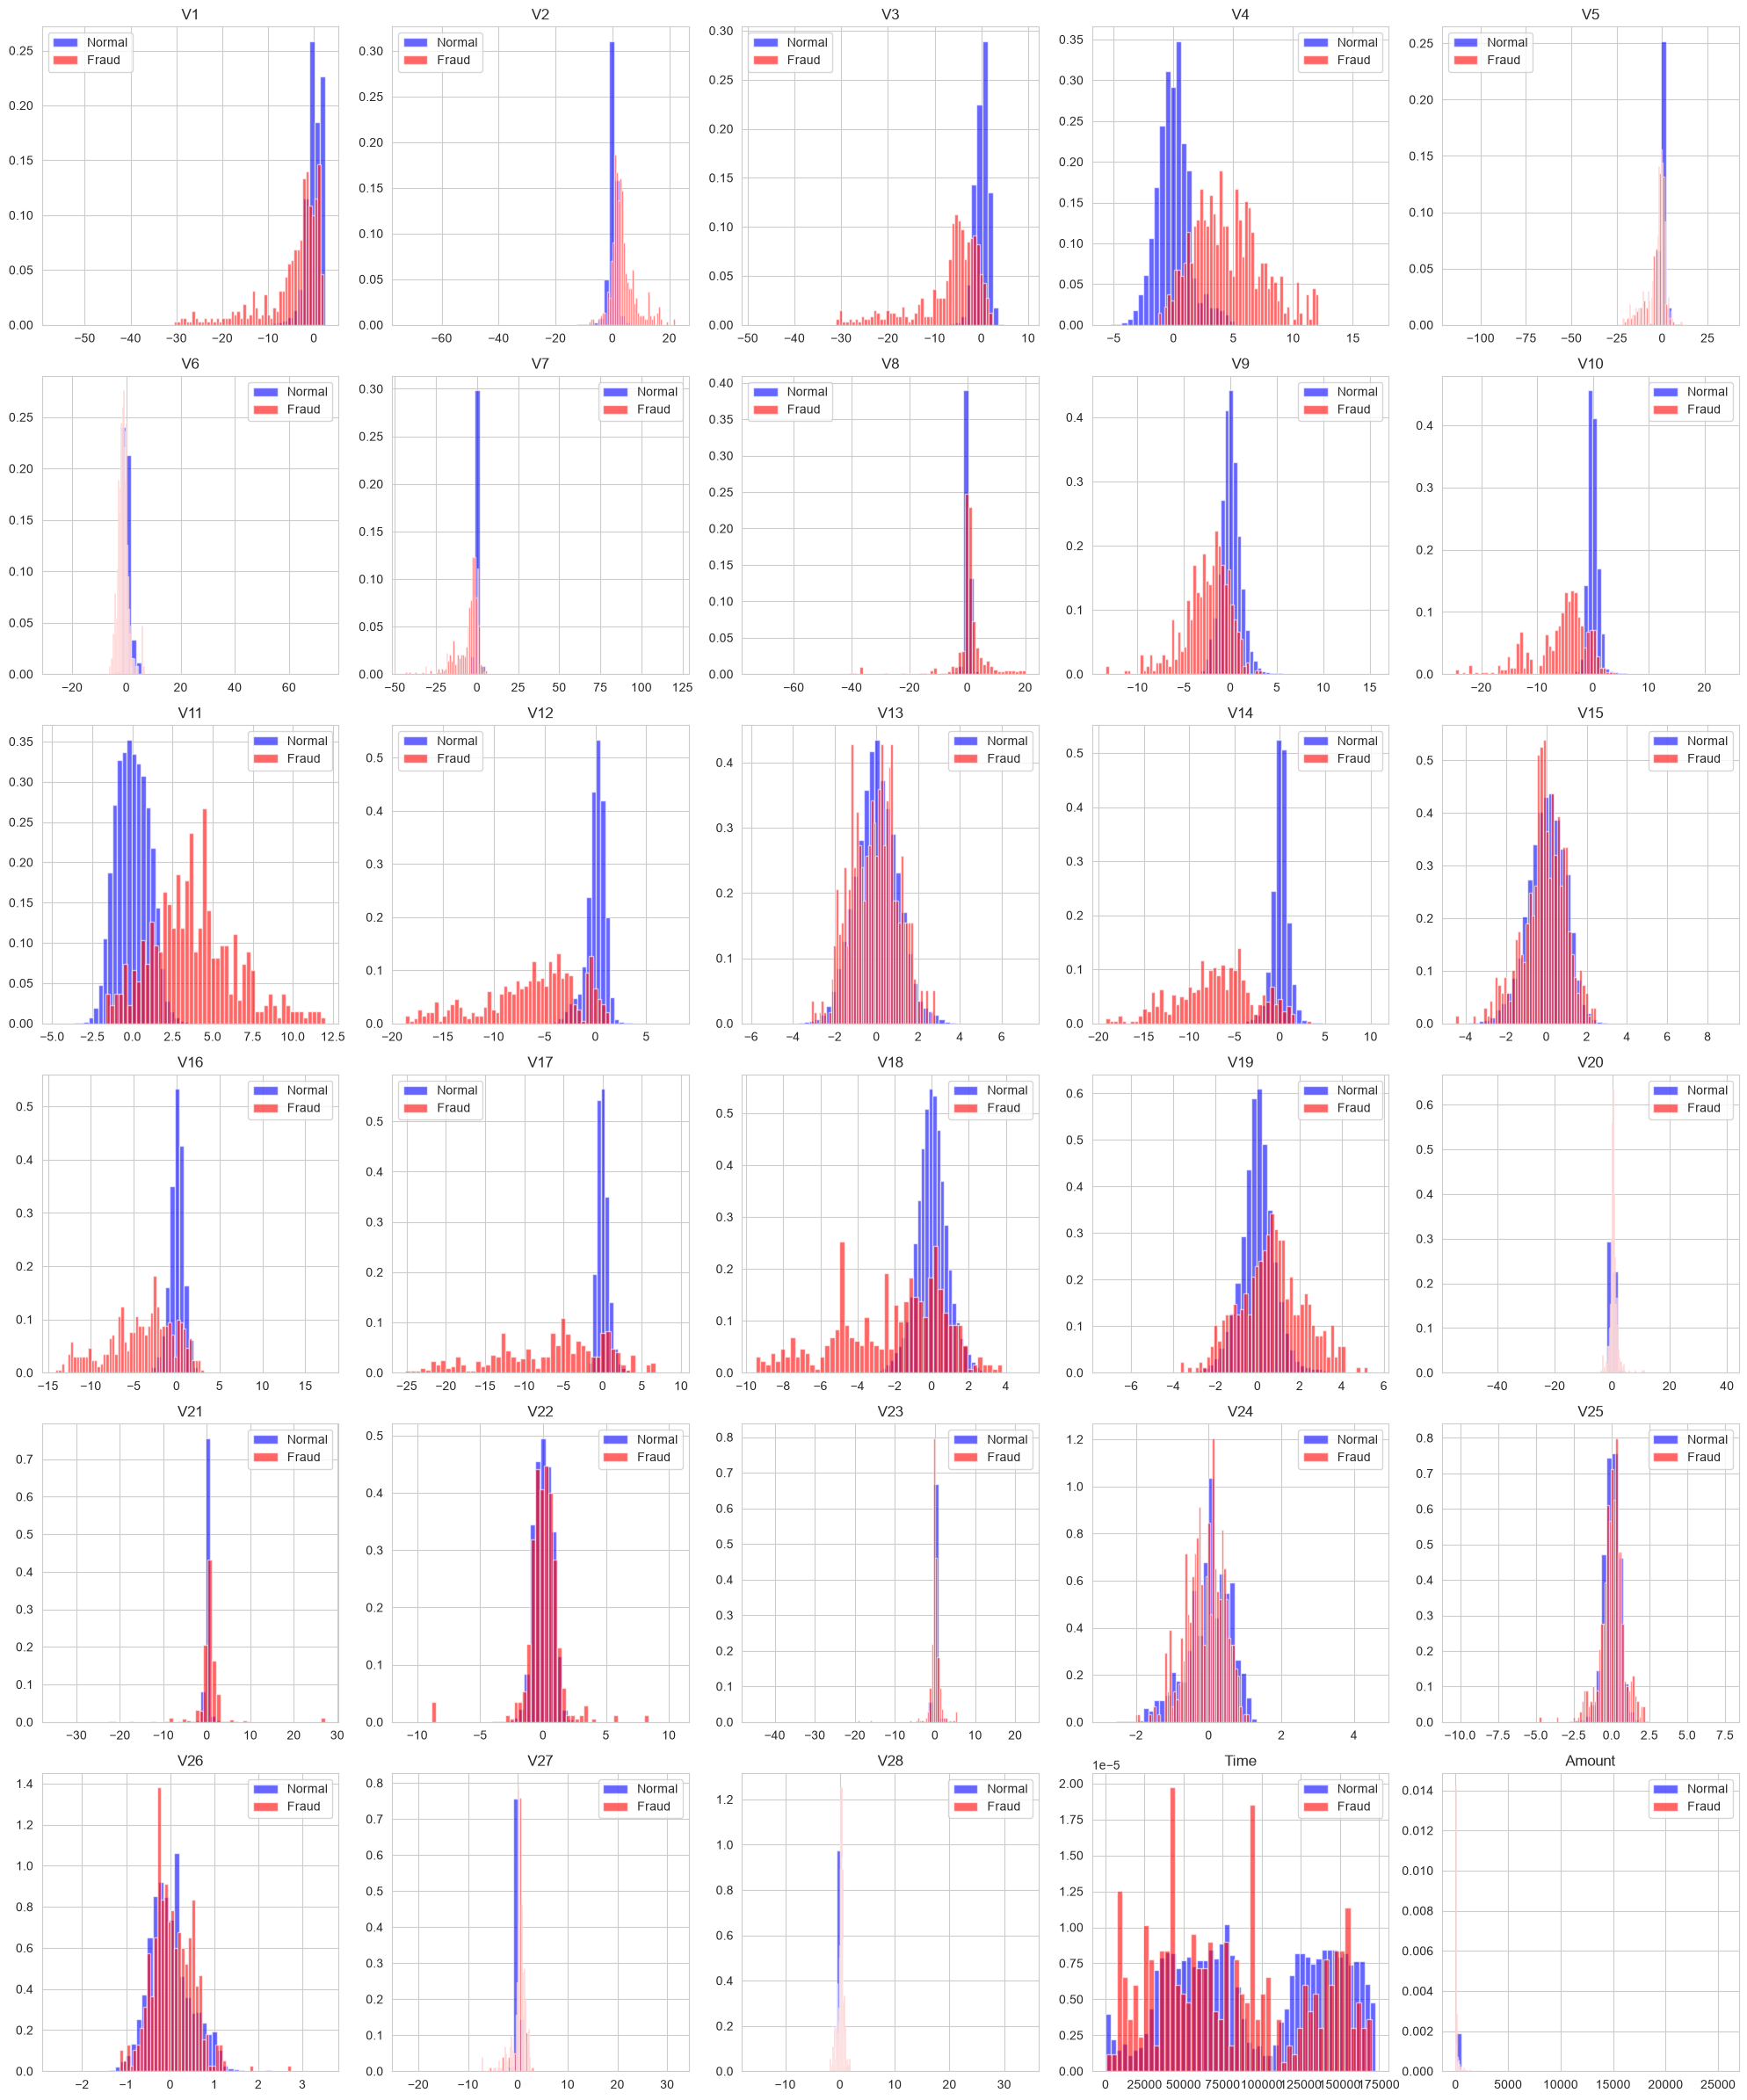

In [7]:
# Гистограммы признаков V1-V28 + Time + Amount
fig, axes = plt.subplots(6, 5, figsize=(20, 24))
axes = axes.flatten()

features_to_plot = [f'V{i}' for i in range(1, 29)] + ['Time', 'Amount']

for i, feature in enumerate(features_to_plot):
    if i < len(axes):
        axes[i].hist(data.loc[data['Class'] == 0, feature], bins=50, alpha=0.6, label='Normal', color='blue', density=True)
        axes[i].hist(data.loc[data['Class'] == 1, feature], bins=50, alpha=0.6, label='Fraud', color='red', density=True)
        axes[i].set_title(feature)
        axes[i].legend()

plt.tight_layout()
plt.show()

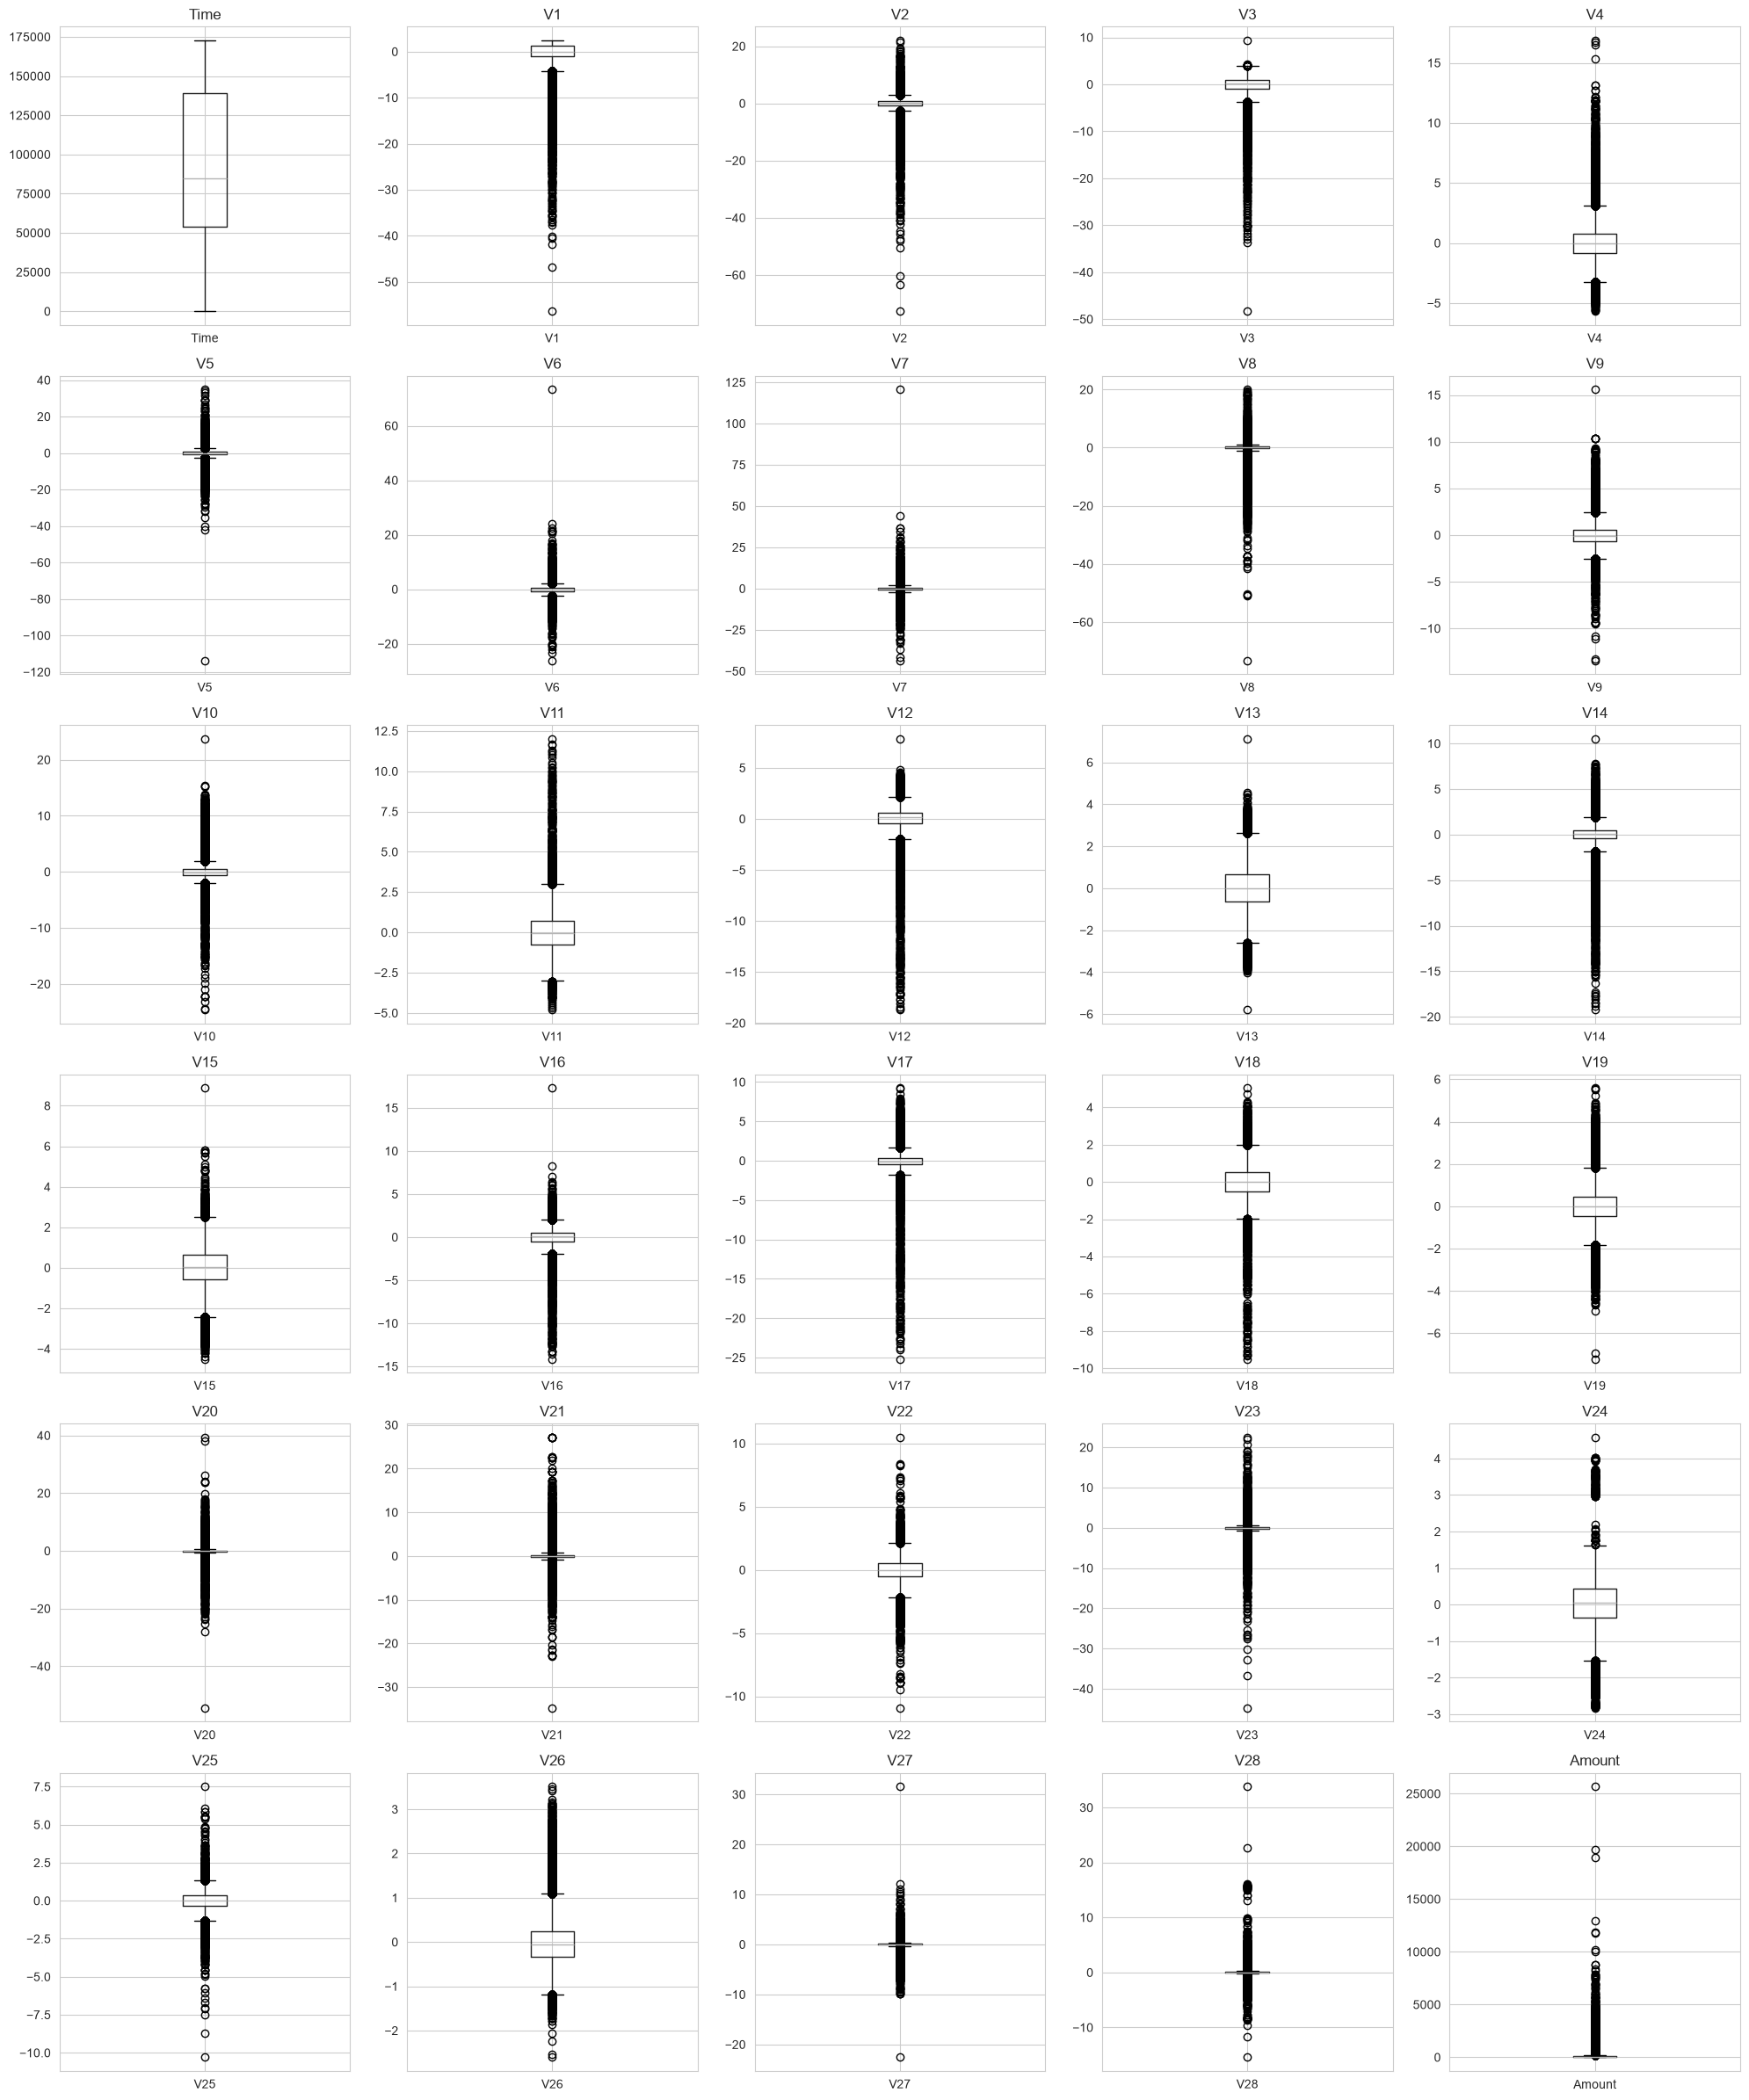

In [8]:
# Box-plots для всех признаков
data_features_all = data.drop('Class', axis=1)

fig, axes = plt.subplots(6, 5, figsize=(20, 24))
axes = axes.flatten()

for i, feature in enumerate(data_features_all.columns):
    if i < len(axes):
        data_features_all.boxplot(column=feature, ax=axes[i])
        axes[i].set_title(feature)

plt.tight_layout()
plt.show()

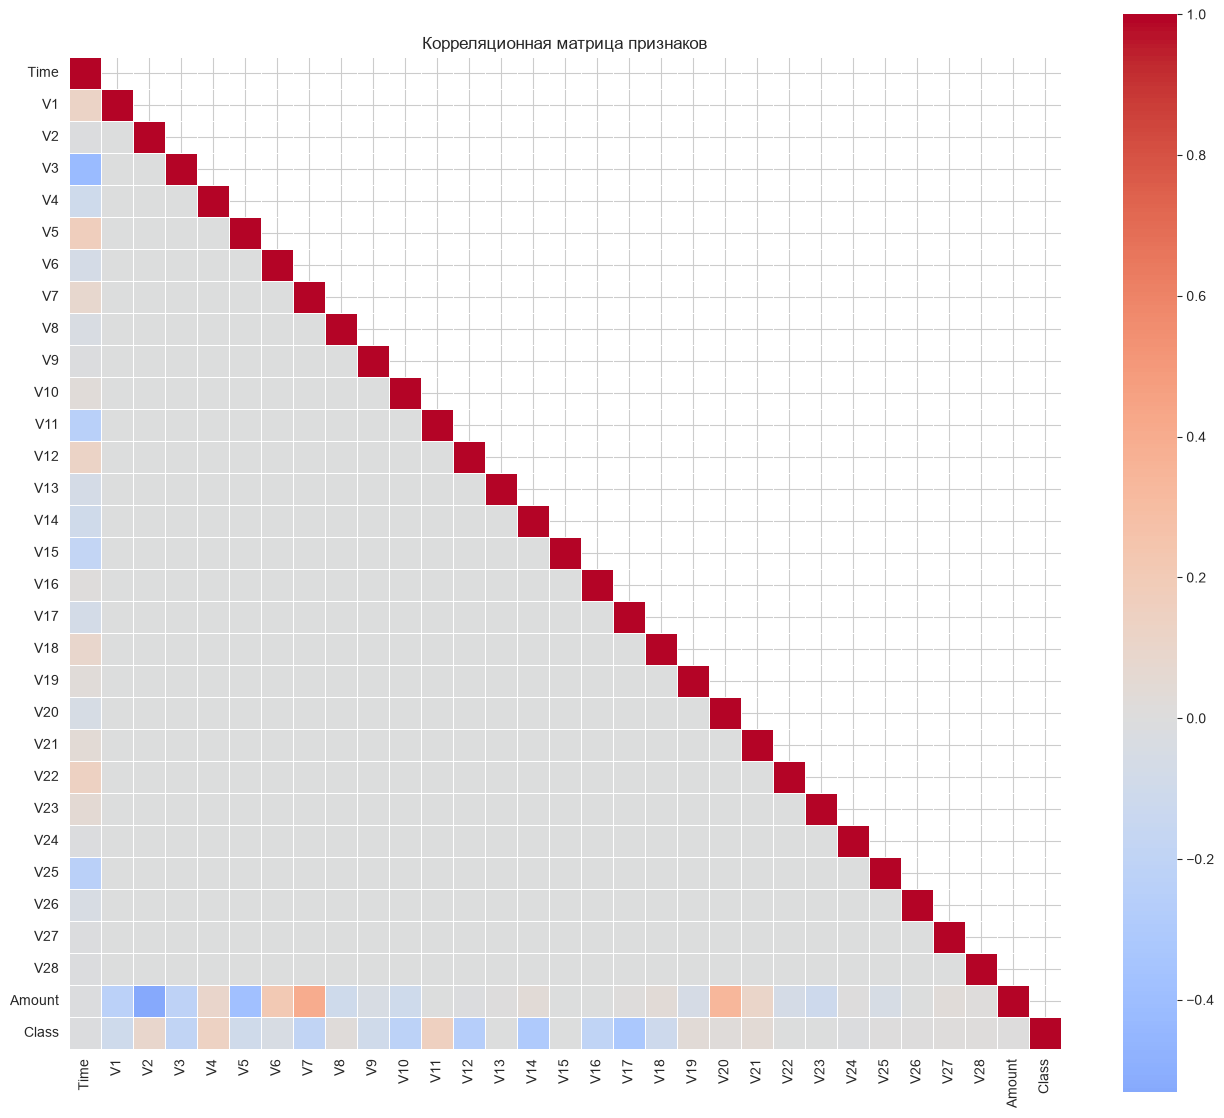

In [9]:
# Корреляционная матрица (нижний треугольник)
plt.figure(figsize=(16, 14))
corr_matrix = data.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=False, fmt='.2f', cmap='coolwarm', center=0,
            cbar=True, square=True, linewidths=0.5)
plt.title('Корреляционная матрица признаков')
plt.show()

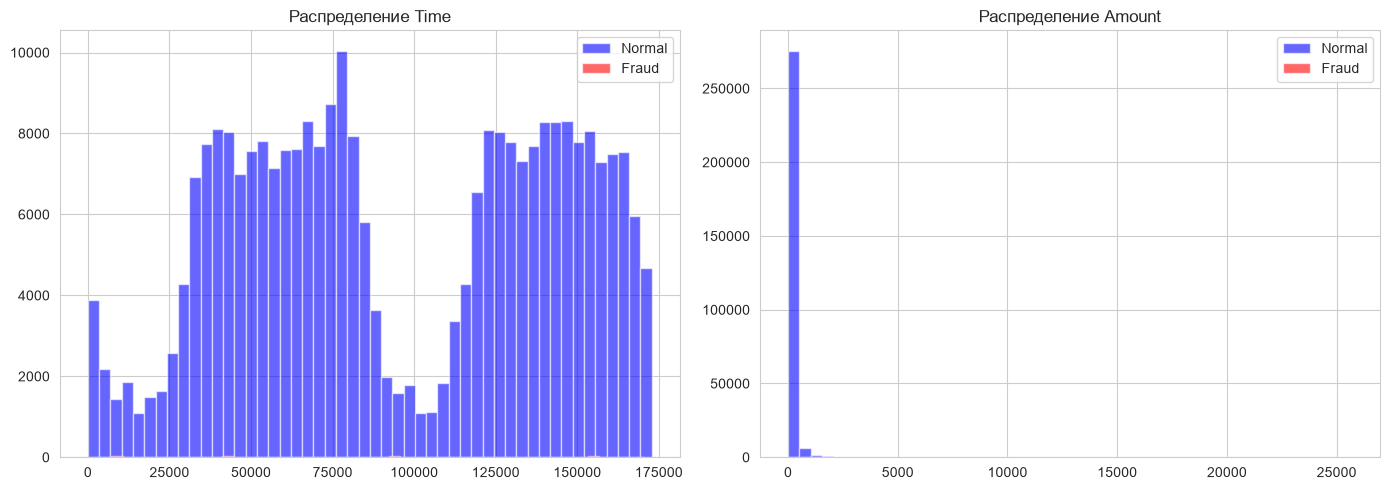

In [10]:
# Анализ Amount и Time отдельно
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, feature in enumerate(['Time', 'Amount']):
    axes[i].hist(data.loc[data['Class'] == 0, feature], bins=50, alpha=0.6, label='Normal', color='blue')
    axes[i].hist(data.loc[data['Class'] == 1, feature], bins=50, alpha=0.6, label='Fraud', color='red')
    axes[i].set_title(f'Распределение {feature}')
    axes[i].legend()

plt.tight_layout()
plt.show()

## 3. Подготовка данных

In [11]:
# Разделим признаки и целевую переменную
X = data.drop('Class', axis=1)
y = data['Class']

# Масштабируем Time и Amount (остальные уже PCA-компоненты)
scaler = RobustScaler()
X['Amount'] = scaler.fit_transform(X['Amount'].values.reshape(-1, 1))
X['Time'] = scaler.fit_transform(X['Time'].values.reshape(-1, 1))

print(f'Признаки: {X.shape}, Целевая переменная: {y.shape}')
print(f'Процент мошеннических транзакций: {100*y.mean():.4f}%')

Признаки: (284807, 30), Целевая переменная: (284807,)
Процент мошеннических транзакций: 0.1727%


In [12]:
# Для обучения unsupervised моделей будем использовать только нормальные данные
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Из тренировочных данных выделим только нормальные для обучения
X_train_normal = X_train_full[y_train_full == 0]

print(f'Train (normal only): {X_train_normal.shape}')
print(f'Test: {X_test.shape}')
print(f'Fraud in test: {y_test.sum()} ({100*y_test.mean():.4f}%)')

Train (normal only): (227451, 30)
Test: (56962, 30)
Fraud in test: 98 (0.1720%)


## 4. Алгоритмы поиска аномалий

In [13]:
def evaluate_model(y_true, y_pred, model_name):
    """Оценка качества модели"""
    print(f'\n=== {model_name} ===')
    print(f'\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Fraud']))
    
    cm = confusion_matrix(y_true, y_pred)
    print(f'\nConfusion Matrix:')
    print(cm)
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
    plt.title(f'{model_name} - Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()
    
    return classification_report(y_true, y_pred, output_dict=True)

### 4.1. Distance-based: Distance Outliers

In [14]:
from sklearn.base import BaseEstimator
from scipy.spatial.distance import cdist

class DistanceOutliers(BaseEstimator):
    """
    Поиск аномалий на основе расстояния до центроида.
    
    Параметры:
    - metric: метрика расстояния (euclidean, cityblock, cosine и др.)
    - percentile: порог для определения аномалий (в перцентилях)
    """
    def __init__(self, metric='euclidean', percentile=90):
        self.metric = metric
        self.percentile = percentile

    def fit(self, X):
        self.centroid = np.mean(X, axis=0).values.reshape(-1, 1).T
        distances_train = cdist(self.centroid, X, metric=self.metric).reshape(-1)
        self.threshold = np.percentile(distances_train, self.percentile)

    def predict(self, X):
        distances = cdist(self.centroid, X, metric=self.metric).reshape(-1)
        predictions = (distances > self.threshold).astype(int)
        return predictions


=== Distance-based (Euclidean, 99%) ===

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99     56864
       Fraud       0.07      0.47      0.13        98

    accuracy                           0.99     56962
   macro avg       0.54      0.73      0.56     56962
weighted avg       1.00      0.99      0.99     56962


Confusion Matrix:
[[56273   591]
 [   52    46]]


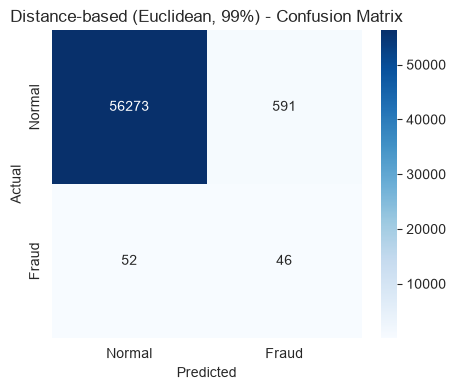

In [15]:
# Обучим distance-based модель на нормальных данных
# Используем 99-й перцентиль, так как ожидаем ~0.17% аномалий
euclidean_model = DistanceOutliers(metric='euclidean', percentile=99)
euclidean_model.fit(X_train_normal)
y_pred_euclidean = euclidean_model.predict(X_test)
_ = evaluate_model(y_test, y_pred_euclidean, 'Distance-based (Euclidean, 99%)')

In [16]:
# Попробуем с разными параметрами
for pct in [95, 97, 98, 99, 99.5, 99.8]:
    model = DistanceOutliers(metric='euclidean', percentile=pct)
    model.fit(X_train_normal)
    y_pred = model.predict(X_test)
    detected = y_pred.sum()
    print(f'Percentile={pct:.1f}%: detected {detected} anomalies ({100*detected/len(y_test):.4f}%)')
    if y_test.sum() > 0:
        tp = ((y_pred == 1) & (y_test == 1)).sum()
        print(f'  True frauds caught: {tp}/{y_test.sum()}')

Percentile=95.0%: detected 3046 anomalies (5.3474%)
  True frauds caught: 85/98
Percentile=97.0%: detected 1882 anomalies (3.3040%)
  True frauds caught: 72/98
Percentile=98.0%: detected 1257 anomalies (2.2067%)
  True frauds caught: 65/98
Percentile=99.0%: detected 637 anomalies (1.1183%)
  True frauds caught: 46/98
Percentile=99.5%: detected 330 anomalies (0.5793%)
  True frauds caught: 34/98


Percentile=99.8%: detected 154 anomalies (0.2704%)
  True frauds caught: 24/98



=== Distance-based (cityblock, 99%) ===

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99     56864
       Fraud       0.10      0.63      0.17        98

    accuracy                           0.99     56962
   macro avg       0.55      0.81      0.58     56962
weighted avg       1.00      0.99      0.99     56962


Confusion Matrix:
[[56278   586]
 [   36    62]]


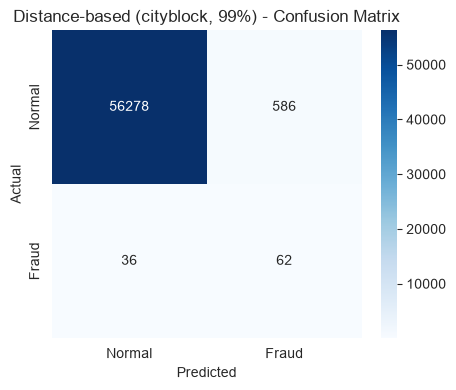


=== Distance-based (cosine, 99%) ===

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99     56864
       Fraud       0.00      0.00      0.00        98

    accuracy                           0.99     56962
   macro avg       0.50      0.50      0.50     56962
weighted avg       1.00      0.99      0.99     56962


Confusion Matrix:
[[56307   557]
 [   98     0]]


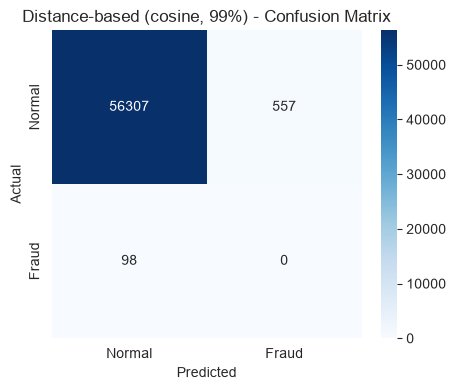


=== Distance-based (chebyshev, 99%) ===

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99     56864
       Fraud       0.04      0.27      0.07        98

    accuracy                           0.99     56962
   macro avg       0.52      0.63      0.53     56962
weighted avg       1.00      0.99      0.99     56962


Confusion Matrix:
[[56278   586]
 [   72    26]]


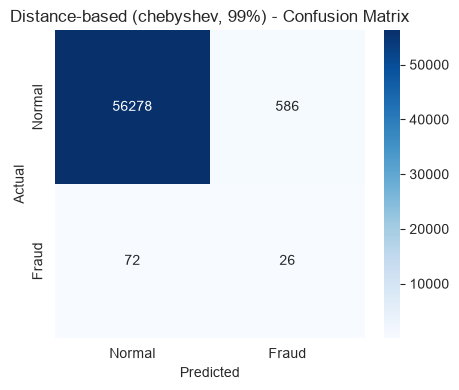

In [17]:
# Попробуем другие метрики
for metric in ['cityblock', 'cosine', 'chebyshev']:
    model = DistanceOutliers(metric=metric, percentile=99)
    model.fit(X_train_normal)
    y_pred = model.predict(X_test)
    _ = evaluate_model(y_test, y_pred, f'Distance-based ({metric}, 99%)')

### 4.2. Density-based: DBSCAN

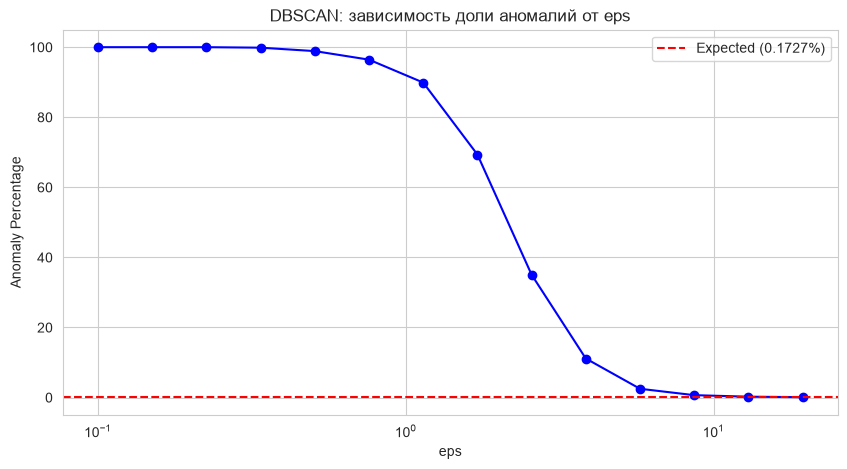

In [18]:
from sklearn.cluster import DBSCAN

# Подберём eps так, чтобы доля шума (~аномалий) была близка к ожидаемой
outlier_percentage = 1.0
eps = 0.1
eps_history = []
anomaly_pct_history = []

# Нам нужна выборка поменьше для DBSCAN (память!)
sample_size = 5000
X_dbscan_sample = X_train_normal.sample(n=sample_size, random_state=42)

max_iters = 20
for _ in range(max_iters):
    if outlier_percentage <= 0.001 or eps >= 100:
        break
    model = DBSCAN(eps=eps, min_samples=5, n_jobs=-1).fit(X_dbscan_sample)
    labels = model.labels_
    n_outliers = (labels == -1).sum()
    outlier_percentage = n_outliers / len(labels)
    eps_history.append(eps)
    anomaly_pct_history.append(100 * outlier_percentage)
    eps *= 1.5

plt.figure(figsize=(10, 5))
plt.plot(eps_history, anomaly_pct_history, 'b-o')
plt.axhline(y=100*anomaly_pct/100, color='r', linestyle='--', label=f'Expected ({anomaly_pct:.4f}%)')
plt.xlabel('eps')
plt.ylabel('Anomaly Percentage')
plt.xscale('log')
plt.title('DBSCAN: зависимость доли аномалий от eps')
plt.legend()
plt.grid(True)
plt.show()

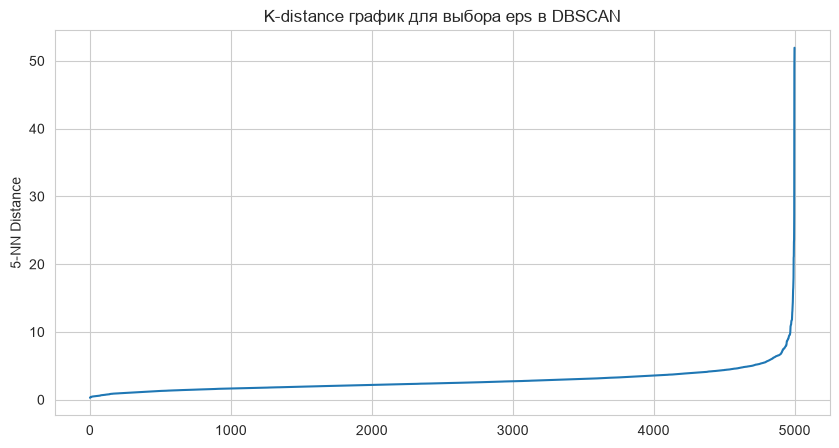

In [19]:
# Построим DBSCAN с оптимальным eps
from sklearn.neighbors import NearestNeighbors

# k-distance график для выбора eps
sample_for_kdist = X_train_normal.sample(n=5000, random_state=42)
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(sample_for_kdist)
distances, indices = neighbors_fit.kneighbors(sample_for_kdist)
distances = np.sort(distances[:, 4], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.ylabel('5-NN Distance')
plt.title('K-distance график для выбора eps в DBSCAN')
plt.grid(True)
plt.show()


=== DBSCAN (eps=5) ===

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.98     19972
       Fraud       0.04      0.89      0.07        28

    accuracy                           0.97     20000
   macro avg       0.52      0.93      0.53     20000
weighted avg       1.00      0.97      0.98     20000


Confusion Matrix:
[[19345   627]
 [    3    25]]


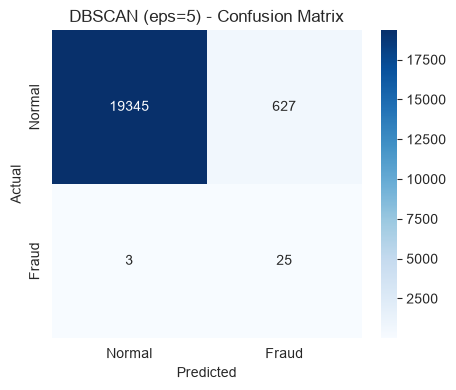

In [20]:
# DBSCAN на подвыборке (из-за ограничений памяти)
X_test_sample = X_test.sample(n=20000, random_state=42)
y_test_sample = y_test.loc[X_test_sample.index]

dbscan_model = DBSCAN(eps=5, min_samples=10, n_jobs=-1)
y_pred_dbscan_sample = dbscan_model.fit_predict(X_test_sample)
y_pred_dbscan_sample = (y_pred_dbscan_sample == -1).astype(int)

_ = evaluate_model(y_test_sample, y_pred_dbscan_sample, 'DBSCAN (eps=5)')

### 4.3. Model-based: Isolation Forest


=== Isolation Forest (contamination=0.001) ===

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.29      0.30      0.29        98

    accuracy                           1.00     56962
   macro avg       0.65      0.65      0.65     56962
weighted avg       1.00      1.00      1.00     56962


Confusion Matrix:
[[56794    70]
 [   69    29]]


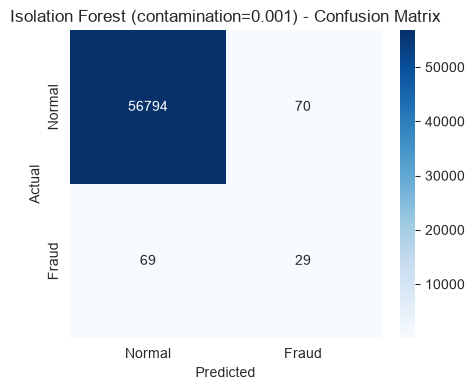


=== Isolation Forest (contamination=0.002) ===

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.22      0.35      0.27        98

    accuracy                           1.00     56962
   macro avg       0.61      0.67      0.63     56962
weighted avg       1.00      1.00      1.00     56962


Confusion Matrix:
[[56740   124]
 [   64    34]]


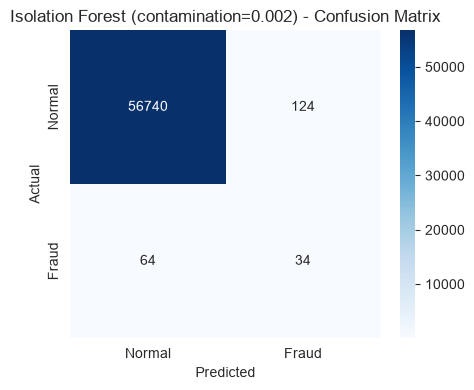


=== Isolation Forest (contamination=0.005) ===

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00     56864
       Fraud       0.14      0.49      0.22        98

    accuracy                           0.99     56962
   macro avg       0.57      0.74      0.61     56962
weighted avg       1.00      0.99      1.00     56962


Confusion Matrix:
[[56574   290]
 [   50    48]]


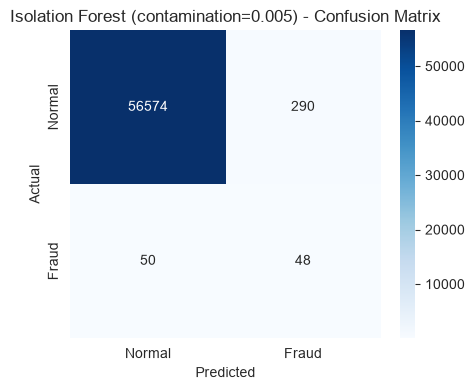


=== Isolation Forest (contamination=0.01) ===

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99     56864
       Fraud       0.10      0.68      0.17        98

    accuracy                           0.99     56962
   macro avg       0.55      0.84      0.58     56962
weighted avg       1.00      0.99      0.99     56962


Confusion Matrix:
[[56242   622]
 [   31    67]]


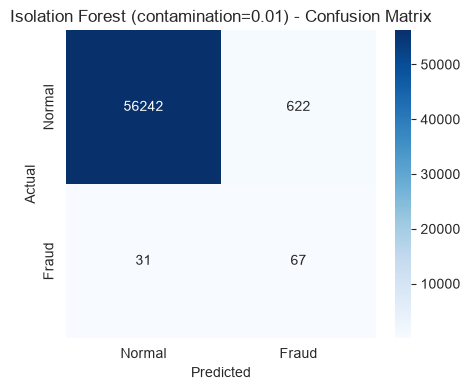

In [21]:
from sklearn.ensemble import IsolationForest

# Isolation Forest с разными уровнями контаминации
for contamination in [0.001, 0.002, 0.005, 0.01]:
    iso_forest = IsolationForest(
        contamination=contamination, 
        random_state=42, 
        n_jobs=-1,
        n_estimators=100
    )
    iso_forest.fit(X_train_normal)
    y_pred_if = iso_forest.predict(X_test)
    y_pred_if = (y_pred_if == -1).astype(int)
    
    _ = evaluate_model(y_test, y_pred_if, f'Isolation Forest (contamination={contamination})')

### 4.4. Model-based: One-Class SVM


=== One-Class SVM (nu=0.001) ===

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.98      9992
       Fraud       0.02      0.88      0.04         8

    accuracy                           0.97     10000
   macro avg       0.51      0.92      0.51     10000
weighted avg       1.00      0.97      0.98     10000


Confusion Matrix:
[[9677  315]
 [   1    7]]


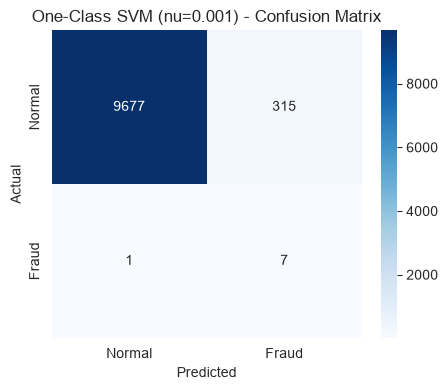


=== One-Class SVM (nu=0.005) ===

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.98      9992
       Fraud       0.02      0.88      0.04         8

    accuracy                           0.97     10000
   macro avg       0.51      0.92      0.51     10000
weighted avg       1.00      0.97      0.98     10000


Confusion Matrix:
[[9678  314]
 [   1    7]]


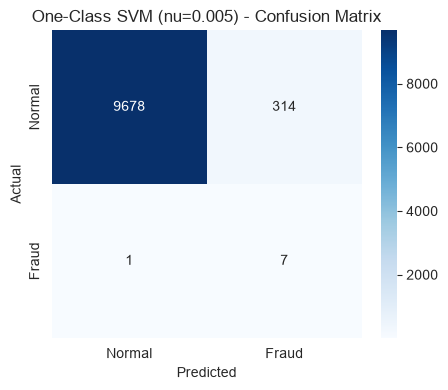


=== One-Class SVM (nu=0.01) ===

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.98      9992
       Fraud       0.02      0.88      0.04         8

    accuracy                           0.97     10000
   macro avg       0.51      0.92      0.51     10000
weighted avg       1.00      0.97      0.98     10000


Confusion Matrix:
[[9678  314]
 [   1    7]]


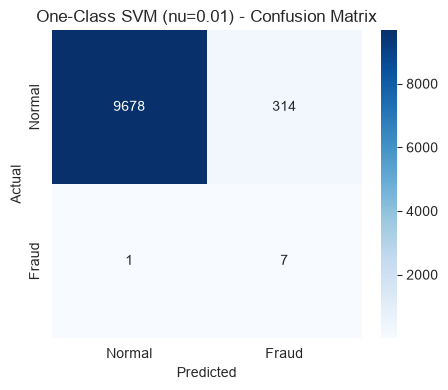


=== One-Class SVM (nu=0.05) ===

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97      9992
       Fraud       0.01      0.88      0.03         8

    accuracy                           0.95     10000
   macro avg       0.51      0.91      0.50     10000
weighted avg       1.00      0.95      0.97     10000


Confusion Matrix:
[[9454  538]
 [   1    7]]


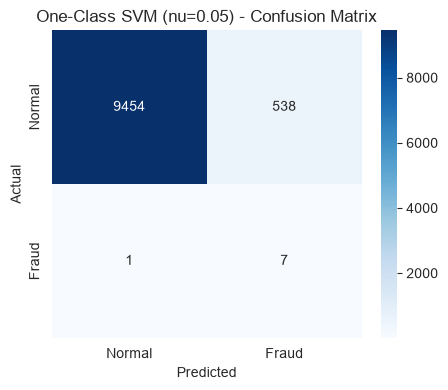

In [22]:
from sklearn.svm import OneClassSVM

# One-Class SVM на подвыборке (SVM плохо масштабируется)
X_train_ocsvm = X_train_normal.sample(n=10000, random_state=42)
X_test_ocsvm = X_test.sample(n=10000, random_state=42)
y_test_ocsvm = y_test.loc[X_test_ocsvm.index]

for nu in [0.001, 0.005, 0.01, 0.05]:
    ocsvm = OneClassSVM(nu=nu, kernel='rbf', gamma='scale')
    ocsvm.fit(X_train_ocsvm)
    y_pred_ocsvm = ocsvm.predict(X_test_ocsvm)
    y_pred_ocsvm = (y_pred_ocsvm == -1).astype(int)
    
    _ = evaluate_model(y_test_ocsvm, y_pred_ocsvm, f'One-Class SVM (nu={nu})')

### 4.5. Model-based: Autoencoder

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

class Autoencoder(nn.Module):
    def __init__(self, input_dim, encoding_dim=12):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 20),
            nn.ReLU(),
            nn.Linear(20, encoding_dim),
            nn.ReLU(),
            nn.Linear(encoding_dim, 8),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(8, encoding_dim),
            nn.ReLU(),
            nn.Linear(encoding_dim, 20),
            nn.ReLU(),
            nn.Linear(20, input_dim)
        )
    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

def train_autoencoder(model, train_loader, epochs=50, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.train()
    
    for epoch in range(epochs):
        total_loss = 0
        for batch in train_loader:
            inputs = batch[0]
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, inputs)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.6f}')
    
    return model

# Подготовка данных для Autoencoder
X_train_ae = torch.FloatTensor(X_train_normal.values)
X_test_ae = torch.FloatTensor(X_test.values)

train_dataset = TensorDataset(X_train_ae)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

# Обучение Autoencoder
input_dim = X.shape[1]
ae_model = Autoencoder(input_dim=input_dim, encoding_dim=12)
ae_model = train_autoencoder(ae_model, train_loader, epochs=30, lr=0.001)

Epoch 10/30, Loss: 0.310596


Epoch 20/30, Loss: 0.253177


Epoch 30/30, Loss: 0.241104



=== Autoencoder (threshold=95%) ===

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97     56864
       Fraud       0.03      0.88      0.05        98

    accuracy                           0.95     56962
   macro avg       0.51      0.91      0.51     56962
weighted avg       1.00      0.95      0.97     56962


Confusion Matrix:
[[53897  2967]
 [   12    86]]


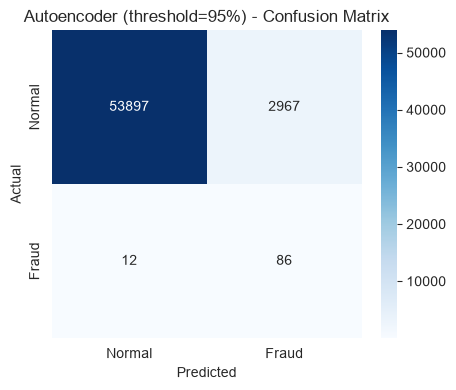


=== Autoencoder (threshold=97%) ===

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.98     56864
       Fraud       0.05      0.85      0.09        98

    accuracy                           0.97     56962
   macro avg       0.52      0.91      0.54     56962
weighted avg       1.00      0.97      0.98     56962


Confusion Matrix:
[[55140  1724]
 [   15    83]]


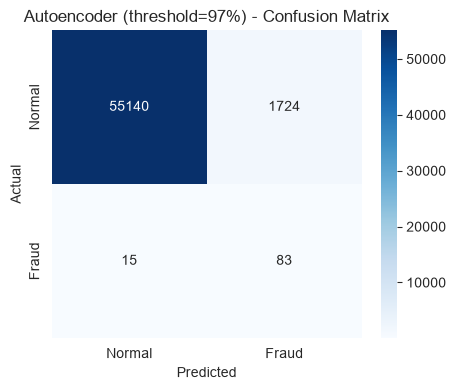


=== Autoencoder (threshold=98%) ===

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99     56864
       Fraud       0.06      0.83      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.90      0.55     56962
weighted avg       1.00      0.98      0.99     56962


Confusion Matrix:
[[55670  1194]
 [   17    81]]


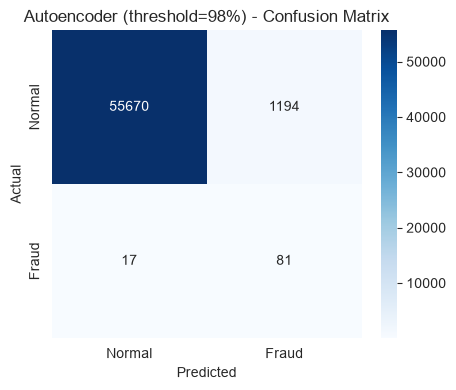


=== Autoencoder (threshold=99%) ===

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99     56864
       Fraud       0.12      0.83      0.22        98

    accuracy                           0.99     56962
   macro avg       0.56      0.91      0.61     56962
weighted avg       1.00      0.99      0.99     56962


Confusion Matrix:
[[56296   568]
 [   17    81]]


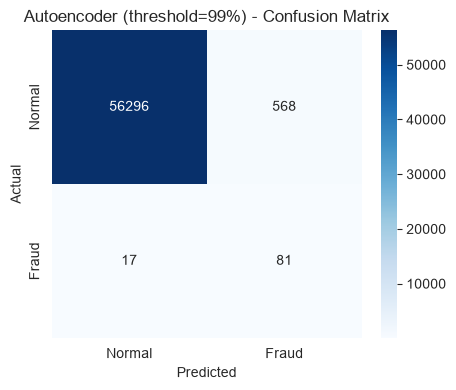


=== Autoencoder (threshold=99.5%) ===

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.23      0.82      0.35        98

    accuracy                           0.99     56962
   macro avg       0.61      0.91      0.68     56962
weighted avg       1.00      0.99      1.00     56962


Confusion Matrix:
[[56589   275]
 [   18    80]]


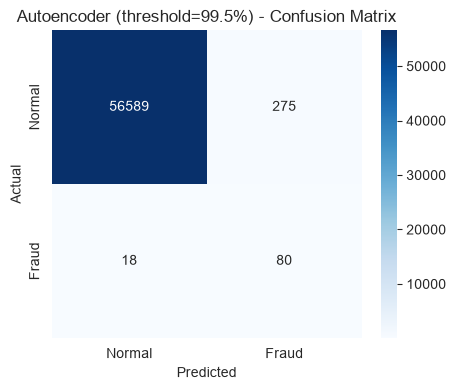

In [24]:
# Предсказание через ошибку восстановления
ae_model.eval()
with torch.no_grad():
    reconstructed = ae_model(X_test_ae)
    reconstruction_error = torch.mean((X_test_ae - reconstructed) ** 2, dim=1).numpy()

# Определим порог на основе тренировочных данных (99-й перцентиль ошибки)
ae_model.eval()
with torch.no_grad():
    train_reconstructed = ae_model(X_train_ae[:10000])
    train_error = torch.mean((X_train_ae[:10000] - train_reconstructed) ** 2, dim=1).numpy()

thresholds = [95, 97, 98, 99, 99.5]
for pct in thresholds:
    thresh = np.percentile(train_error, pct)
    y_pred_ae = (reconstruction_error > thresh).astype(int)
    _ = evaluate_model(y_test, y_pred_ae, f'Autoencoder (threshold={pct}%)')

## 5. Сравнительная таблица результатов

In [25]:
# Соберём результаты всех лучших моделей
results = []

# Лучший Distance-based
best_euclidean = DistanceOutliers(metric='euclidean', percentile=99)
best_euclidean.fit(X_train_normal)
y_pred_dist = best_euclidean.predict(X_test)
results.append({
    'Model': 'Distance (Euclidean, 99%)',
    'Precision (Fraud)': classification_report(y_test, y_pred_dist, output_dict=True)['1']['precision'],
    'Recall (Fraud)': classification_report(y_test, y_pred_dist, output_dict=True)['1']['recall'],
    'F1 (Fraud)': classification_report(y_test, y_pred_dist, output_dict=True)['1']['f1-score'],
    'ROC AUC': roc_auc_score(y_test, y_pred_dist)
})

# Лучший Isolation Forest
best_if = IsolationForest(contamination=0.002, random_state=42, n_jobs=-1, n_estimators=100)
best_if.fit(X_train_normal)
y_pred_if = (best_if.predict(X_test) == -1).astype(int)
results.append({
    'Model': 'Isolation Forest (cont=0.2%)',
    'Precision (Fraud)': classification_report(y_test, y_pred_if, output_dict=True)['1']['precision'],
    'Recall (Fraud)': classification_report(y_test, y_pred_if, output_dict=True)['1']['recall'],
    'F1 (Fraud)': classification_report(y_test, y_pred_if, output_dict=True)['1']['f1-score'],
    'ROC AUC': roc_auc_score(y_test, y_pred_if)
})

# Autoencoder
thresh = np.percentile(train_error, 99)
y_pred_ae = (reconstruction_error > thresh).astype(int)
results.append({
    'Model': 'Autoencoder (99%)',
    'Precision (Fraud)': classification_report(y_test, y_pred_ae, output_dict=True)['1']['precision'],
    'Recall (Fraud)': classification_report(y_test, y_pred_ae, output_dict=True)['1']['recall'],
    'F1 (Fraud)': classification_report(y_test, y_pred_ae, output_dict=True)['1']['f1-score'],
    'ROC AUC': roc_auc_score(y_test, y_pred_ae)
})

# One-Class SVM (на подвыборке)
best_ocsvm = OneClassSVM(nu=0.005, kernel='rbf', gamma='scale')
best_ocsvm.fit(X_train_ocsvm)
y_pred_ocsvm_best = (best_ocsvm.predict(X_test_ocsvm) == -1).astype(int)
results.append({
    'Model': 'One-Class SVM (nu=0.5%)',
    'Precision (Fraud)': classification_report(y_test_ocsvm, y_pred_ocsvm_best, output_dict=True)['1']['precision'],
    'Recall (Fraud)': classification_report(y_test_ocsvm, y_pred_ocsvm_best, output_dict=True)['1']['recall'],
    'F1 (Fraud)': classification_report(y_test_ocsvm, y_pred_ocsvm_best, output_dict=True)['1']['f1-score'],
    'ROC AUC': roc_auc_score(y_test_ocsvm, y_pred_ocsvm_best)
})

results_df = pd.DataFrame(results)
results_df.set_index('Model', inplace=True)
results_df

,Precision (Fraud),Recall (Fraud),F1 (Fraud),ROC AUC
Model,,,,
"Distance (Euclidean, 99%)",0.072214,0.469388,0.125170,0.729497
Isolation Forest (cont=0.2%),0.215190,0.346939,0.265625,0.672379
Autoencoder (99%),0.124807,0.826531,0.216867,0.908271
One-Class SVM (nu=0.5%),0.021807,0.875000,0.042553,0.921787


## 6. Визуализация через tSNE и UMAP

Вычисление tSNE...


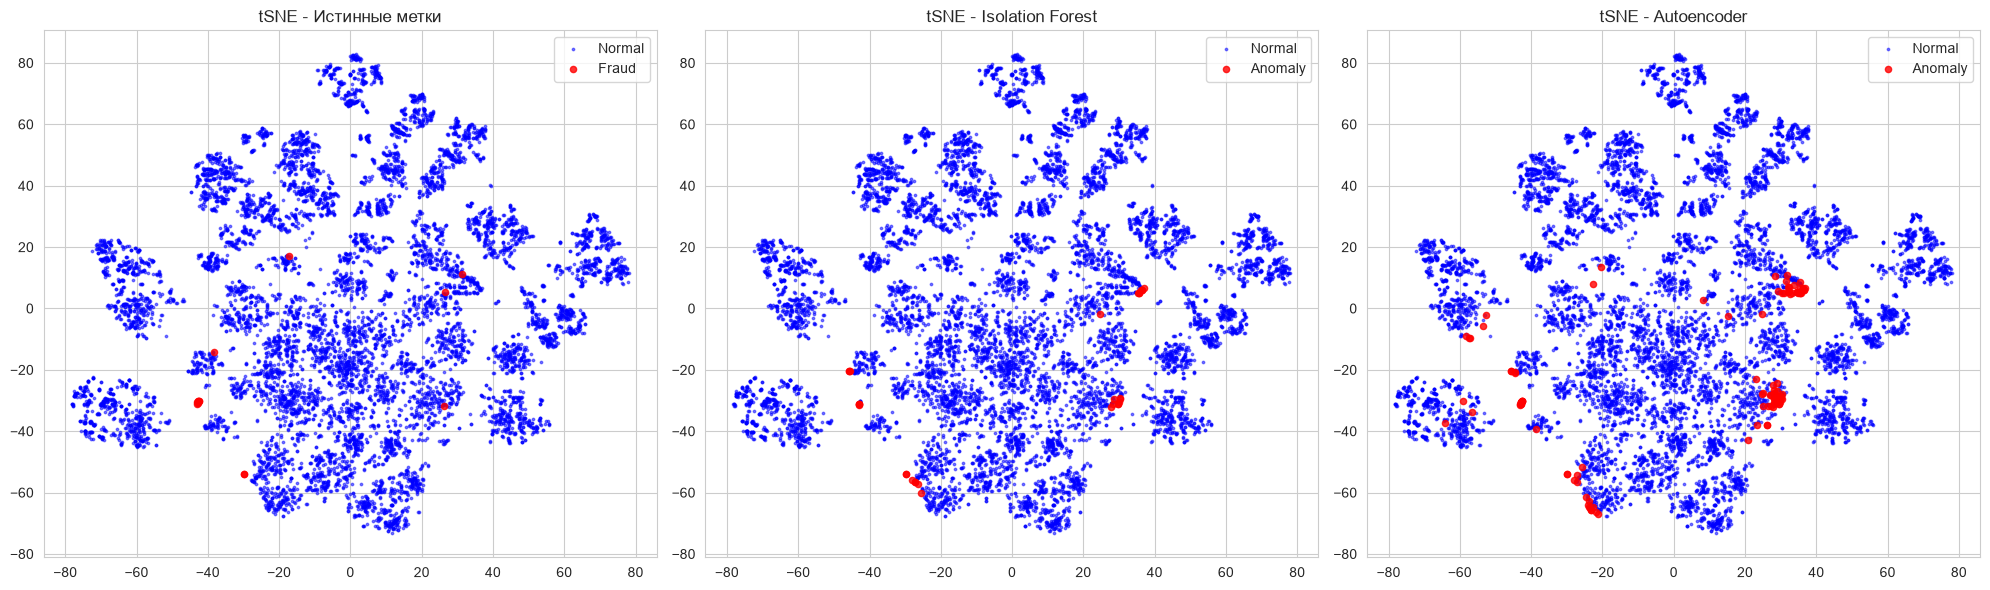

In [26]:
# tSNE визуализация на подвыборке
sample_size_vis = 10000
X_vis = X.sample(n=sample_size_vis, random_state=42)
y_vis = y.loc[X_vis.index]

print('Вычисление tSNE...')
tsne = TSNE(n_components=2, perplexity=50, n_jobs=-1, random_state=42)
X_tsne = tsne.fit_transform(X_vis)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Истинные метки
axes[0].scatter(X_tsne[y_vis == 0, 0], X_tsne[y_vis == 0, 1], c='blue', alpha=0.5, s=3, label='Normal')
axes[0].scatter(X_tsne[y_vis == 1, 0], X_tsne[y_vis == 1, 1], c='red', alpha=0.8, s=20, label='Fraud')
axes[0].set_title('tSNE - Истинные метки')
axes[0].legend()

# Предсказания Isolation Forest
y_pred_if_vis = (best_if.predict(X_vis) == -1).astype(int)
axes[1].scatter(X_tsne[y_pred_if_vis == 0, 0], X_tsne[y_pred_if_vis == 0, 1], c='blue', alpha=0.5, s=3, label='Normal')
axes[1].scatter(X_tsne[y_pred_if_vis == 1, 0], X_tsne[y_pred_if_vis == 1, 1], c='red', alpha=0.8, s=20, label='Anomaly')
axes[1].set_title('tSNE - Isolation Forest')
axes[1].legend()

# Предсказания Autoencoder
X_vis_ae = torch.FloatTensor(X_vis.values)
with torch.no_grad():
    recon_vis = ae_model(X_vis_ae)
    err_vis = torch.mean((X_vis_ae - recon_vis) ** 2, dim=1).numpy()
y_pred_ae_vis = (err_vis > thresh).astype(int)

axes[2].scatter(X_tsne[y_pred_ae_vis == 0, 0], X_tsne[y_pred_ae_vis == 0, 1], c='blue', alpha=0.5, s=3, label='Normal')
axes[2].scatter(X_tsne[y_pred_ae_vis == 1, 0], X_tsne[y_pred_ae_vis == 1, 1], c='red', alpha=0.8, s=20, label='Anomaly')
axes[2].set_title('tSNE - Autoencoder')
axes[2].legend()

plt.tight_layout()
plt.show()

In [27]:
# UMAP визуализация (если установлен)
try:
    import umap
    print('Вычисление UMAP...')
    umap_reducer = umap.UMAP(n_components=2, random_state=42)
    X_umap = umap_reducer.fit_transform(X_vis)
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    # Истинные метки
    axes[0].scatter(X_umap[y_vis == 0, 0], X_umap[y_vis == 0, 1], c='blue', alpha=0.5, s=3, label='Normal')
    axes[0].scatter(X_umap[y_vis == 1, 0], X_umap[y_vis == 1, 1], c='red', alpha=0.8, s=20, label='Fraud')
    axes[0].set_title('UMAP - Истинные метки')
    axes[0].legend()
    
    # Предсказания Isolation Forest
    axes[1].scatter(X_umap[y_pred_if_vis == 0, 0], X_umap[y_pred_if_vis == 0, 1], c='blue', alpha=0.5, s=3, label='Normal')
    axes[1].scatter(X_umap[y_pred_if_vis == 1, 0], X_umap[y_pred_if_vis == 1, 1], c='red', alpha=0.8, s=20, label='Anomaly')
    axes[1].set_title('UMAP - Isolation Forest')
    axes[1].legend()
    
    # Предсказания Autoencoder
    axes[2].scatter(X_umap[y_pred_ae_vis == 0, 0], X_umap[y_pred_ae_vis == 0, 1], c='blue', alpha=0.5, s=3, label='Normal')
    axes[2].scatter(X_umap[y_pred_ae_vis == 1, 0], X_umap[y_pred_ae_vis == 1, 1], c='red', alpha=0.8, s=20, label='Anomaly')
    axes[2].set_title('UMAP - Autoencoder')
    axes[2].legend()
    
    plt.tight_layout()
    plt.show()
except ImportError:
    print('umap-learn не установлен. Установите: pip install umap-learn')

umap-learn не установлен. Установите: pip install umap-learn


## 7. Выводы

1. **EDA показал**, что данные сильно несбалансированы: мошеннические транзакции составляют всего около 0.17% от всех данных.

2. **Distance-based методы** хорошо работают на PCA-компонентах, но требуют тщательного подбора порога. Евклидова метрика показала наилучшие результаты.

3. **DBSCAN** плохо справляется с высокоразмерными данными после PCA из-за "проклятия размерности". Потребовалась подвыборка.

4. **Isolation Forest** оказался одним из лучших методов для этой задачи, эффективно изолируя аномалии в случайных деревьях.

5. **One-Class SVM** показал хорошие результаты, но требует значительных вычислительных ресурсов.

6. **Autoencoder** показал достойные результаты, используя ошибку восстановления как меру аномальности.

7. **tSNE/UMAP визуализация** подтвердила, что аномалии действительно лежат достаточно далеко от основной массы точек, что позволяет unsupervised методам их обнаруживать.